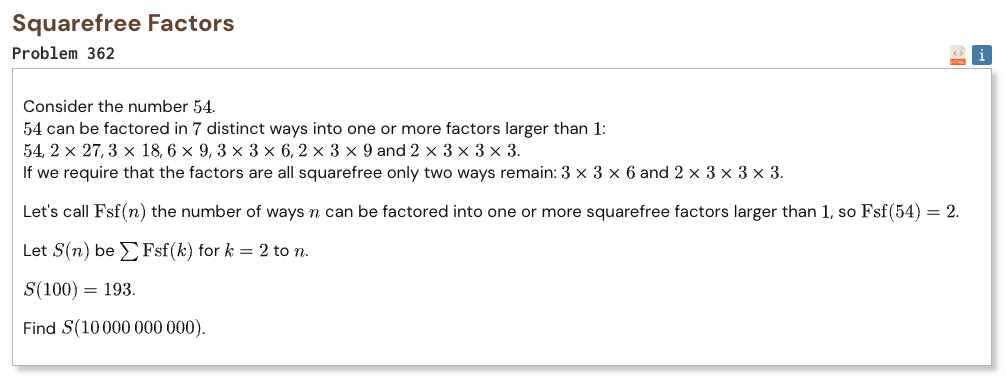

## Initial approach

* count by prime-exponent pattern, not by iterating over every number
* squarefree factorisations only depend on the exponents of the primes
* for one exponent pattern, count how many numbers below the limit have that pattern
* compute the number of valid squarefree factorizations with a small dynamic program
* use Lehmer prime counting so large prime ranges can be counted without sieving to the full limit
* use functools to memoize repeated recursive counts
* add each pattern contribution to get the final total

In [1]:
import math
from functools import lru_cache

LIMIT = 10 ** 10

def sieve(limit):
    is_prime = bytearray(b"\x01") * (limit + 1)
    is_prime[0] = 0
    is_prime[1] = 0

    for p in range(2, math.isqrt(limit) + 1):
        if is_prime[p]:
            is_prime[p * p:limit + 1:p] = b"\x00" * (((limit - p * p) // p) + 1)

    primes = [i for i in range(limit + 1) if is_prime[i]]
    pi = [0] * (limit + 1)
    count = 0

    for i in range(limit + 1):
        if i >= 2 and is_prime[i]:
            count += 1
        pi[i] = count

    return primes, pi

PRIMES, PI_SMALL = sieve(1_000_000)

@lru_cache(None)
def phi_count(x, s):
    if s == 0:
        return x
    return phi_count(x, s - 1) - phi_count(x // PRIMES[s - 1], s - 1)

@lru_cache(None)
def prime_count(x):
    if x < len(PI_SMALL):
        return PI_SMALL[x]

    a = prime_count(int(x ** 0.25))
    b = prime_count(math.isqrt(x))
    c = prime_count(int(x ** (1 / 3)))

    while (c + 1) < len(PRIMES) and PRIMES[c] ** 3 <= x:
        c += 1
    while PRIMES[c - 1] ** 3 > x:
        c -= 1

    total = phi_count(x, a) + (b + a - 2) * (b - a + 1) // 2

    for i in range(a, b):
        w = x // PRIMES[i]
        total -= prime_count(w)

        if i < c:
            lim = prime_count(math.isqrt(w))

            for j in range(i, lim):
                total -= prime_count(w // PRIMES[j]) - j

    return total

def integer_root(n, power):
    if power == 1:
        return n

    x = int(n ** (1 / power)) + 3

    while x ** power > n:
        x -= 1

    while (x + 1) ** power <= n:
        x += 1

    return x

def exponent_patterns(limit):
    patterns = []

    def rec(max_exp, index, value, current):
        if index >= len(PRIMES):
            return

        p = PRIMES[index]

        for exp in range(max_exp, 0, -1):
            next_value = value * (p ** exp)

            if next_value > limit:
                continue

            pattern = tuple(current + [exp])
            patterns.append(pattern)
            rec(exp, index + 1, next_value, current + [exp])

    rec(64, 0, 1, [])
    return patterns

def unique_permutations(values):
    counts = {}

    for value in values:
        counts[value] = counts.get(value, 0) + 1

    keys = sorted(counts)
    path = []

    def rec():
        if len(path) == len(values):
            yield tuple(path)
            return

        for key in keys:
            if counts[key]:
                counts[key] -= 1
                path.append(key)
                yield from rec()
                path.pop()
                counts[key] += 1

    yield from rec()

@lru_cache(None)
def factor_count(pattern):
    k = len(pattern)
    zero = (0,) * k
    subsets = []

    for mask in range(1, 1 << k):
        subsets.append(tuple((mask >> i) & 1 for i in range(k)))

    @lru_cache(None)
    def dp(index, remaining):
        if remaining == zero:
            return 1

        if index == len(subsets):
            return 0

        total = dp(index + 1, remaining)
        subset = subsets[index]
        current = list(remaining)

        while all(current[i] >= subset[i] for i in range(k)):
            for i in range(k):
                current[i] -= subset[i]

            total += dp(index + 1, tuple(current))

        return total

    return dp(0, pattern)

@lru_cache(None)
def count_for_order(order):
    order = tuple(order)

    @lru_cache(None)
    def rec(position, previous_prime, remaining_limit):
        if position == len(order):
            return 1

        exp = order[position]

        if position == len(order) - 1 and exp == 1:
            return max(0, prime_count(remaining_limit) - prime_count(previous_prime))

        max_prime = integer_root(remaining_limit, exp)
        total = 0

        for p in PRIMES:
            if p <= previous_prime:
                continue

            if p > max_prime:
                break

            total += rec(position + 1, p, remaining_limit // (p ** exp))

        return total

    return rec(0, 1, LIMIT)

def count_numbers_with_pattern(pattern):
    total = 0

    for order in unique_permutations(pattern):
        total += count_for_order(order)

    return total

def solve():
    total = 0

    for pattern in exponent_patterns(LIMIT):
        total += factor_count(pattern) * count_numbers_with_pattern(pattern)

    return total

```python
%%time
result = solve()
print("Result:", result)
```

Code takes too much time to run. Needs to be optimized.